In [2]:
# ============================================================
# CELL 1 — GPU Setup
# ============================================================
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus}")
    except RuntimeError as e:
        print(e)
else:
    print("❌ No GPU detected, running on CPU")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# CELL 2 — Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib, os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("✅ Imports done")

✅ Imports done


In [4]:
# ============================================================
# CELL 3 — Load Feature Columns from Client-1
# (ensures both clients use identical 890 features)
# ============================================================

FEATURE_COLS_PATH = "/kaggle/input/datasets/muhammadasad29/ember24-feature-cols/ember24_client1_feature_cols.json"

with open(FEATURE_COLS_PATH, "r") as f:
    feature_cols = json.load(f)

print(f"✅ Loaded {len(feature_cols)} feature columns from Client-1")
print("First 5:", feature_cols[:5])
print("Last  5:", feature_cols[-5:])

✅ Loaded 890 feature columns from Client-1
First 5: ['byteentropy_0', 'byteentropy_1', 'byteentropy_10', 'byteentropy_100', 'byteentropy_101']
Last  5: ['strings_string_counts_token', 'strings_string_counts_url', 'strings_string_counts_useragent', 'strings_string_counts_wallet', 'strings_string_counts_window']


In [5]:
# ============================================================
# CELL 4 — Load Train & Test Parquets
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/muhammadasad29/ember24/New folder"

TRAIN_PATH = f"{DATASET_PATH}/ember24_win64_train.parquet"
TEST_PATH  = f"{DATASET_PATH}/ember24_win64_test.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

LABEL_COL = "label"

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("\nTrain label distribution:")
print(train_df[LABEL_COL].value_counts())
print("\nTest label distribution:")
print(test_df[LABEL_COL].value_counts())

Train shape: (720000, 898)
Test  shape: (160000, 945)

Train label distribution:
label
1    360000
0    360000
Name: count, dtype: int64

Test label distribution:
label
1    80000
0    80000
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 5 — Create Client-2 Partition (non-IID, skewed)
# 50% of total data BUT skewed: 80% malware, 20% benign
# This simulates a security vendor seeing mostly malware
# ============================================================

malware_df = train_df[train_df[LABEL_COL] == 1].sample(frac=1, random_state=42)
benign_df  = train_df[train_df[LABEL_COL] == 0].sample(frac=1, random_state=42)

client_size = int(0.5 * len(train_df))   # 50% of total train

mal_count = int(0.8 * client_size)       # 80% malware
ben_count = int(0.2 * client_size)       # 20% benign

# Cap to available samples
mal_count = min(mal_count, len(malware_df))
ben_count = min(ben_count, len(benign_df))

client2_df = pd.concat([
    malware_df.iloc[:mal_count],
    benign_df.iloc[:ben_count]
]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Client-2 shape:", client2_df.shape)
print("\nClient-2 label distribution:")
print(client2_df[LABEL_COL].value_counts())
print(f"\nMalware ratio: {client2_df[LABEL_COL].mean():.2f}  (intentionally ~0.80)")

Client-2 shape: (360000, 898)

Client-2 label distribution:
label
1    288000
0     72000
Name: count, dtype: int64

Malware ratio: 0.80  (intentionally ~0.80)


In [7]:
# ============================================================
# CELL 6 — Align to Client-1 Feature Columns
# ============================================================

# Check which of the 890 features are missing in train/test
missing_in_train = [c for c in feature_cols if c not in client2_df.columns]
missing_in_test  = [c for c in feature_cols if c not in test_df.columns]

print(f"Features missing in train : {len(missing_in_train)}")
print(f"Features missing in test  : {len(missing_in_test)}")

if missing_in_train:
    print("Missing in train:", missing_in_train)
if missing_in_test:
    print("Missing in test:", missing_in_test)

# Add missing columns as NaN (will be filled in next cell)
for col in missing_in_train:
    client2_df[col] = np.nan
for col in missing_in_test:
    test_df[col] = np.nan

print("\n✅ Both dataframes now have all 890 feature columns")

Features missing in train : 0
Features missing in test  : 0

✅ Both dataframes now have all 890 feature columns


In [8]:
# ============================================================
# CELL 7 — Fix NaNs + Feature Scaling
# ============================================================

X_train_df = client2_df[feature_cols].copy()
X_test_df  = test_df[feature_cols].copy()

print("=== NaN Check (before fix) ===")
print(f"Train NaN cols : {X_train_df.isna().any().sum()} / {len(feature_cols)}")
print(f"Test  NaN cols : {X_test_df.isna().any().sum()} / {len(feature_cols)}")

# Fill NaNs with column median (fit on client-2 train only)
col_medians = X_train_df.median()
X_train_df = X_train_df.fillna(col_medians)
X_test_df  = X_test_df.fillna(col_medians)

assert X_train_df.isna().sum().sum() == 0, "❌ Still NaNs in train!"
assert X_test_df.isna().sum().sum()  == 0, "❌ Still NaNs in test!"
print("\n✅ NaNs fixed")

# Drop zero-variance columns (if any)
std = X_train_df.std()
constant_cols = std[std == 0].index.tolist()
if constant_cols:
    print(f"⚠️  Dropping {len(constant_cols)} constant columns: {constant_cols}")
    X_train_df = X_train_df.drop(columns=constant_cols)
    X_test_df  = X_test_df.drop(columns=constant_cols)
else:
    print("✅ No constant columns found")

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype("float32")
X_test  = scaler.transform(X_test_df).astype("float32")

y_train = client2_df[LABEL_COL].values.astype("float32")
y_test  = test_df[LABEL_COL].values.astype("float32")

assert not np.isnan(X_train).any(), "❌ NaNs in X_train after scaling!"
assert not np.isnan(X_test).any(),  "❌ NaNs in X_test after scaling!"

print(f"\n✅ Scaling done")
print(f"  X_train mean ≈ {X_train.mean():.4f}  (should be ~0)")
print(f"  X_train std  ≈ {X_train.std():.4f}  (should be ~1)")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test  shape: {X_test.shape}")

=== NaN Check (before fix) ===
Train NaN cols : 273 / 890
Test  NaN cols : 273 / 890

✅ NaNs fixed
✅ No constant columns found

✅ Scaling done
  X_train mean ≈ -0.0000  (should be ~0)
  X_train std  ≈ 1.0000  (should be ~1)
  X_train shape: (360000, 890)
  X_test  shape: (160000, 890)


In [10]:
# ============================================================
# CELL 8 — Build MLP Model
# (same architecture as Client-1 for FedAvg compatibility)
# ============================================================

n_features = X_train.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       456,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,545 (2.37 MB)

 Trainable params: 620,545 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ============================================================
# CELL 9 — Train Model
# ============================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete")

Epoch 1/30


I0000 00:00:1777852681.172528     148 service.cc:152] XLA service 0x7887980051c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777852681.172595     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777852681.172600     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777852681.806520     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


 40/633 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7918 - loss: 0.4829

I0000 00:00:1777852684.885173     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


633/633 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8938 - loss: 0.2602 - val_accuracy: 0.9453 - val_loss: 0.1370
Epoch 2/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9427 - loss: 0.1473 - val_accuracy: 0.9518 - val_loss: 0.1224
Epoch 3/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9493 - loss: 0.1288 - val_accuracy: 0.9546 - val_loss: 0.1151
Epoch 4/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9527 - loss: 0.1208 - val_accuracy: 0.9552 - val_loss: 0.1094
Epoch 5/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9541 - loss: 0.1155 - val_accuracy: 0.9578 - val_loss: 0.1033
Epoch 6/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9564 - loss: 0.1114 - val_accuracy: 0.9601 - val_loss: 0.0993
Epoch 7/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9578 - loss: 0.1075 - val_accuracy: 0.9606 - val_loss: 0.1010
Epoch 8/30
633/633 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9590 - loss: 0.1034 - val_accuracy: 0.9643 - va

In [12]:
# ============================================================
# CELL 10 — Evaluate on Test Set
# ============================================================

y_pred_prob = model.predict(X_test).ravel()
y_pred      = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_pred_prob)

print("=" * 47)
print("   CLIENT-2 (EMBER 2024, non-IID) — TEST RESULTS")
print("=" * 47)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  ROC-AUC  : {roc:.4f}")
print("=" * 47)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
   CLIENT-2 (EMBER 2024, non-IID) — TEST RESULTS
  Accuracy : 0.8875
  F1 Score : 0.8866
  ROC-AUC  : 0.9081

Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.90      0.89     80000
     Malware       0.89      0.88      0.89     80000

    accuracy                           0.89    160000
   macro avg       0.89      0.89      0.89    160000
weighted avg       0.89      0.89      0.89    160000



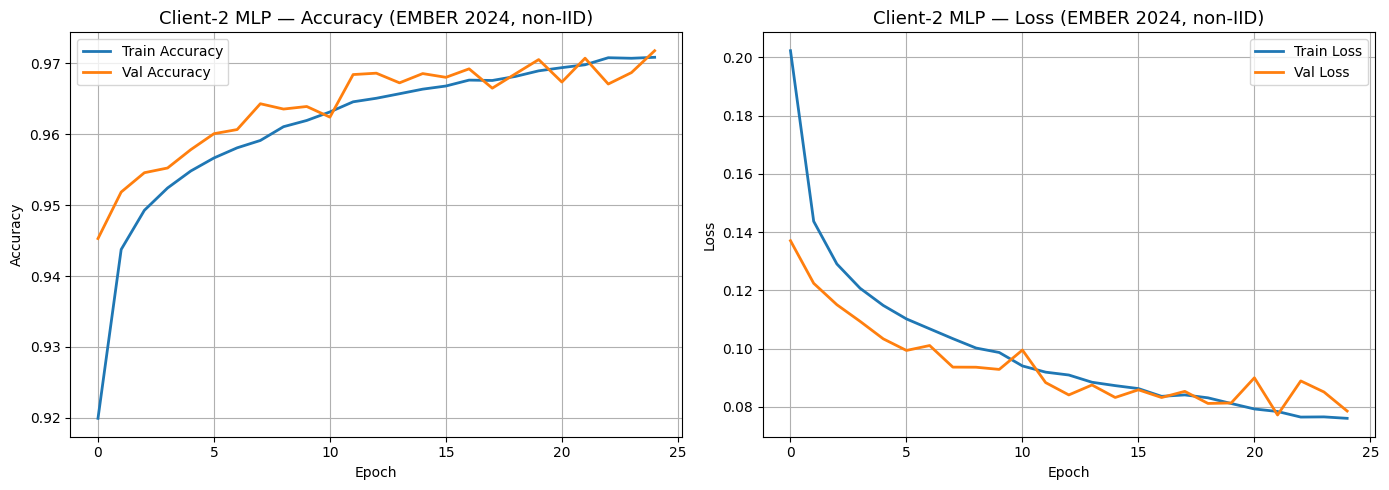

✅ Saved: client2_training_curves.png


In [13]:
# ============================================================
# CELL 11 — Training Curves Plot
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[0].set_title('Client-2 MLP — Accuracy (EMBER 2024, non-IID)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[1].set_title('Client-2 MLP — Loss (EMBER 2024, non-IID)', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/client2_training_curves.png", dpi=150)
plt.show()
print("✅ Saved: client2_training_curves.png")

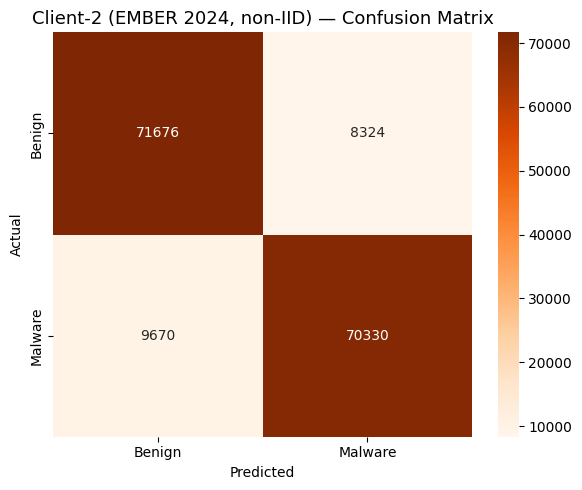

✅ Saved: client2_confusion_matrix.png


In [14]:
# ============================================================
# CELL 12 — Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=["Benign", "Malware"],
    yticklabels=["Benign", "Malware"]
)
plt.title("Client-2 (EMBER 2024, non-IID) — Confusion Matrix", fontsize=13)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/kaggle/working/client2_confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: client2_confusion_matrix.png")

In [15]:
# ============================================================
# CELL 13 — Save Everything to /kaggle/working/
# ============================================================

# Full Keras model
model.save("/kaggle/working/ember24_client2_mlp.keras")
print("✅ ember24_client2_mlp.keras")

# Weights only (for FedAvg)
model.save_weights("/kaggle/working/ember24_client2_weights.weights.h5")
print("✅ ember24_client2_weights.weights.h5")

# Scaler
joblib.dump(scaler, "/kaggle/working/ember24_client2_scaler.pkl")
print("✅ ember24_client2_scaler.pkl")

# Results summary
results = {
    "Client"       : ["Client-2 (MLP, non-IID, EMBER 2024)"],
    "Data Size"    : [X_train.shape[0]],
    "Features"     : [X_train.shape[1]],
    "Malware Ratio": [round(client2_df[LABEL_COL].mean(), 2)],
    "Accuracy"     : [round(acc, 4)],
    "F1 Score"     : [round(f1, 4)],
    "ROC-AUC"      : [round(roc, 4)],
}

pd.DataFrame(results).to_csv("/kaggle/working/client2_results.csv", index=False)
print("✅ client2_results.csv")

print("\nSummary:")
print(pd.DataFrame(results).to_string(index=False))

✅ ember24_client2_mlp.keras
✅ ember24_client2_weights.weights.h5
✅ ember24_client2_scaler.pkl
✅ client2_results.csv

Summary:
                             Client  Data Size  Features  Malware Ratio  Accuracy  F1 Score  ROC-AUC
Client-2 (MLP, non-IID, EMBER 2024)     360000       890            0.8    0.8875    0.8866   0.9081
